This document was a direct conversion of behav_visualizations to a notebook

In [4]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import glob
import re
import shutil
from scipy.signal import butter, filtfilt
from scipy.signal import medfilt
from scipy.signal import savgol_filter

In [1]:
def get_txt_path(directory):
    '''
    This function returns any file under directory that has RoiSet.zip in the filename

    Parameters
    ----------
    directory : str
        The path to the directory to search.

    Returns
    -------
    roi_set_zip : str or None
        The file path to the RoiSet.zip file, or None if not found.
    '''
    # Search for RoiSet.zip in the directory
    txt_files = glob.glob(os.path.join(directory, '**', '*.txt'), recursive=True)
    # Check if any RoiSet.zip files were found
    if len(txt_files) == 0:
        print("No .txt files found.")
        return None
    return txt_files

def get_txt_df(filepath):
    if os.path.getsize(filepath) == 0:
        print(f"Skipping {filepath}: File is empty")
        return None  # Skip empty files

    #includes substantial preprocessing to make a useable dataframe!
    df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
    df = df.reset_index()
    #alt labels = df.columns[-2:]
    df.drop(labels=['index',2,3],axis=1,inplace=True) ##flag this, causing errors in new setup help
    df.rename(columns={0: 'Timestamp', 1: 'Print'}, inplace=True)
    #extract data from print statements
    df['Print'] = df['Print'].astype(str)
    df = df[~df['Print'].str.contains('Solenoid pin state')]
    df['Sensor'] = df['Print'].str.extract(r'(lick|bar)', expand=False)
    df['Value'] = df['Print'].str.extract(r'(\d+)', expand=False).astype(float)
    df['Solenoid'] = df['Print'].str.contains('Solenoid Activated').astype(bool)
    df.drop(labels=['Print'],axis=1,inplace=True)
    #remove rows where solenoid is false and sensor is nan
    df = df[~(df['Sensor'].isna() & (df['Solenoid'] == 0))]
    #df.dropna(axis=0,inplace=True)
    df = convert_timestamps(df)
    df = lick_detection(df)
    return df

def convert_timestamps(df):
    """
    Convert the Timestamp column to datetime format, ensuring the correct interpretation of hours, minutes, seconds, and milliseconds.
    """
    df['Timestamp'] = df['Timestamp'].str.strip()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f')
    return df

def lick_detection(df, sensor='lick', percentile=0.1, m=2, min_val=15):
    """ detects lick when snesor value is m stdevs above the lowext x percentile 
    thanks chatgpt:)
    Add a boolean column 'Lick_Detected' to the DataFrame, indicating whether a lick was detected.

    Parameters:
    df (pd.DataFrame): The input DataFrame with lick data.
    sensor (str): The sensor to detect licks for, default is 'lick'.
    percentile (float): The percentile to use for the baseline, default is 10th percentile.
    stdev_multiplier (float): The number of standard deviations above the baseline to set the threshold, default is 2.

    Returns:
    pd.DataFrame: The DataFrame with an added 'Lick_Detected' boolean column.
    """
    # Filter the DataFrame to include only the relevant sensor data
    sensor_df = df[df['Sensor'] == sensor]
    # Calculate the baseline using the specified percentile
    baseline_value = sensor_df['Value'].quantile(percentile)
    # Calculate the standard deviation
    stdev_value = sensor_df['Value'].std()
    # Set the lick detection threshold
    threshold = baseline_value + m * stdev_value
    # Add a boolean column indicating whether each value exceeds the threshold
    df['Lick_Detected'] = False
    df.loc[df['Sensor'] == sensor, 'Lick_Detected'] = sensor_df['Value'] > threshold
    df.loc[df['Sensor'] == sensor, 'Lick_Detected'] = sensor_df['Value'] > min_val
    return df


In [2]:
def downsample(data, factor):
    return data[::factor]

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def median_filter(data, kernel_size=3):
    return medfilt(data, kernel_size=kernel_size)

def get_sampling_rate(df):
    #gets me a sampling rate for each sensor! direct chatgpt, but hey it works.
    if not pd.api.types.is_datetime64_any_dtype(df['Timestamp']):
        # Step 1: Clean the 'Timestamp' column by stripping whitespace
        df['Timestamp'] = df['Timestamp'].str.strip()
        # Step 2: Convert 'Timestamp' column to datetime with error handling
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f', errors='coerce')
        # Check for any rows where the conversion failed (i.e., where Timestamp is NaT)
        failed_conversions = df[df['Timestamp'].isna()]
        if not failed_conversions.empty:
            print("Rows with failed Timestamp conversions:")
            print(failed_conversions)
    # Step 3: Calculate time differences for each sensor if conversion was successful
    df['Time_Diff'] = df.groupby('Sensor')['Timestamp'].diff()
    # Step 4: Calculate the sampling frequency for each sensor
    sampling_freq = df.groupby('Sensor')['Time_Diff'].apply(lambda x: 1 / x.mean().total_seconds())
    # Display the results
    #df.drop(['Time_Diff'])
    df.drop(['Time_Diff'], axis=1, inplace=True, errors='ignore')
    print(sampling_freq)
    return(sampling_freq)


In [6]:
filepath = '/Users/emmaodom/MIT Dropbox/Emma Odom/Emma/Reach_Task_Master/lick_reaching_data/402R/402R_Reach2_20250225_170429.txt'
df = get_txt_df(filepath)
sr = get_sampling_rate(df)

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


Sensor
bar     125.533517
lick    146.305779
Name: Time_Diff, dtype: float64


In [7]:
#maybe downsample before simple visualizaiton plots... 
#cant downsample lick and bar the same factpr (temporal res of lick sensor is way more important than the bar temporal resolution)
import matplotlib.dates as mdates
def basic_plot(df, animal_ID, date, stage, dots = True, which_dots = 'Solenoid'):
    #sort data by sensor type and lineplot 
    lick_df = df[df['Sensor']=='lick'].iloc[::10, :]
    bar_df = df[df['Sensor']=='bar'].iloc[::40, :]
    sns.lineplot(data=lick_df,x='Timestamp',y='Value',label='lick')
    sns.lineplot(data=bar_df,x='Timestamp',y='Value',label='bar')
    #dots for solenoid activations
    if dots:
        dots_df = df[df[which_dots]==True]
        scale = 1.2*bar_df['Value'].max()
        y_ = scale*np.ones_like(dots_df['Value'])
        plt.scatter(dots_df['Timestamp'],y_,color='red',s=2,label=which_dots,zorder=5)
    #set x-ticks 
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45) 
    #label things
    plt.title(f"{stage} Animal {animal_ID} - {date}")
    plt.legend()
    plt.show()   
#example/test call
#basic_plot(df,animal_ID,date,stage='Lick', dots=True, which_dots='Lick_Detected') 

def smoothed_plot(df, animal_ID, date, stage,order=2,kernel_size=30,dots = True, which_dots = 'Solenoid',save=False, directory='none'):
    #fs_lick,fs_bar,cutoff_freq=0.2 used to be inputs for low-pass filter
    # Apply downsampling
    lick_df = df[df['Sensor'] == 'lick'].iloc[::10, :]
    bar_df = df[df['Sensor'] == 'bar'].iloc[::40, :]
    
    # Apply low-pass filter to smooth the data
    #lick_df['Smoothed_Value'] = butter_lowpass_filter(lick_df['Value'], cutoff=cutoff_freq, fs=fs_lick,order=order)
    # Apply a Savitzky-Golay filter
    lick_df['Smoothed_Value'] = savgol_filter(lick_df['Value'], window_length=7, polyorder=2)
    bar_df['Smoothed_Value'] = median_filter(bar_df['Value'], kernel_size=kernel_size)
    
    # Plotting
    sns.lineplot(data=lick_df, x='Timestamp', y='Smoothed_Value', label='lick')
    sns.lineplot(data=bar_df, x='Timestamp', y='Smoothed_Value', label='bar')
    #scatter
    if dots:
        dots_df = df[df[which_dots]==True]
        scale = 1.2*bar_df['Value'].max()
        y_ = scale*np.ones_like(dots_df['Value'])
        plt.scatter(dots_df['Timestamp'],y_,color='red',s=2,label=which_dots,zorder=5)
        
    #set x-ticks 
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45) 
    plt.title(f"{stage} Animal {animal_ID} - {date} \n bar: median_filter lick: savgol_filter")
    plt.legend()
    if save:
        save_path = directory +'/pdf/' + f'{animal_ID}_smoothed_lick_bar_plot.pdf'
        plt.savefig(save_path, format = 'pdf')
    plt.show()


### organize files into folders by animal_ID (with safetys to check current location before moving)

In [20]:
# Define the directory containing the files
source_dir = '//Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
# Get a list of all items in the source directory
files = os.listdir(source_dir)
# Define a pattern to match the animal ID (3 digits followed by 1 letter)
pattern = re.compile(r'^(\d{3}[A-Z])')

# Process each file
for filename in files:
    # Skip if it's a directory
    if os.path.isdir(os.path.join(source_dir, filename)):
        continue
        
    match = pattern.match(filename)
    if match:
        animal_id = match.group(1)
        # Check if file is already in correct folder
        current_path = os.path.join(source_dir, filename)
        if os.path.dirname(current_path) == os.path.join(source_dir, animal_id):
            continue  # Skip if file is already in correct folder
            
        # Create a new directory for this animal ID if it doesn't exist
        save_dir = os.path.join(source_dir, animal_id)
        os.makedirs(save_dir, exist_ok=True)
        
        # Move the file to the new directory
        try:
            shutil.move(current_path, os.path.join(save_dir, filename))
            print(f"Moved {filename} to {animal_id} folder")
        except shutil.Error as e:
            print(f"Error moving {filename}: {e}")

###  delete empty text files

In [ ]:

def delete_empty_txt_files(directory):
    for dirpath, _, filenames in os.walk(directory):
        for file in filenames:
            if file.endswith(".txt"):
                filepath = os.path.join(dirpath, file)
                # Check if the file is empty
                if os.path.getsize(filepath) == 0:
                    print(f"Deleting empty file: {filepath}")
                    os.remove(filepath)

# Example usage
directory_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'  # Replace with the path to your directory
delete_empty_txt_files(directory_path)


### specific single session plot

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


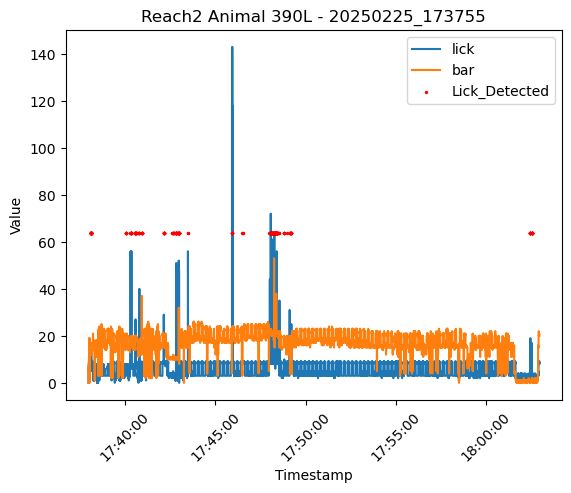

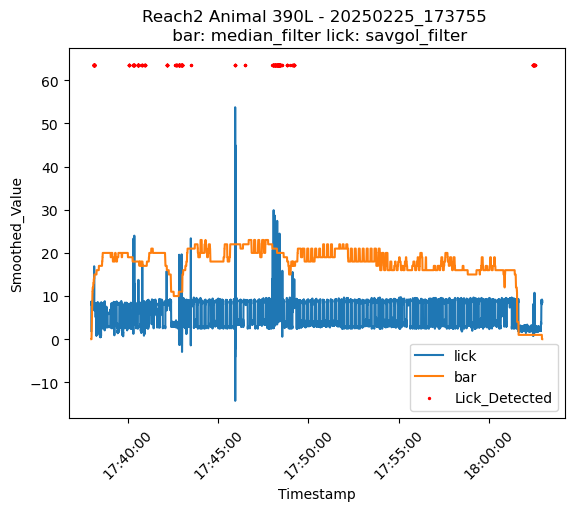

In [ ]:
filepath = '/Users/emmaodom/MIT Dropbox/Emma Odom/Emma/Reach_Task_Master/lick_reaching_data/390L/390L_Reach2_20250225_173755.txt'
#good example file #'/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/277T/277T_LickReach_20240911_212833.txt'
filename = os.path.basename(filepath)
df = get_txt_df(filepath)
# Regular expression to extract animal_ID, stage, and date
pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8}_\d{6})")
# Extracting the components from the filename
match = pattern.match(filename)
if match:
    animal_ID = match.group(1)
    stage = match.group(2)
    date = match.group(3)
basic_plot(df, animal_ID = animal_ID, date=date, stage=stage, dots=True, which_dots='Lick_Detected')
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/visualizations'
smoothed_plot(df, animal_ID = animal_ID, date=date, stage=stage, kernel_size = 99, dots=True, which_dots='Lick_Detected',save=True,directory=save_path)

### plot all sessions. has capability to aggregate the raw data across all sessions

In [13]:
def plot_animal_sessions(animal_id, data_dir, plot_type='basic', session_type=None, max_plots=None):
    """
    Create subplots of all sessions for a given animal, ordered by date.
    
    Parameters
    ----------
    animal_id : str
        Animal ID (e.g. '402R')
    data_dir : str
        Base directory containing behavior data
    plot_type : str, optional
        'basic' or 'smoothed' (default: 'basic')
    session_type : str, optional
        'Lick' or 'Reach' to filter sessions, or None for all sessions
    max_plots : int, optional
        Maximum number of sessions to plot, or None for all
    
    Returns
    -------
    fig : matplotlib figure
        The figure containing all subplots
    """
    # Get animal directory
    animal_dir = os.path.join(data_dir, animal_id)
    if not os.path.exists(animal_dir):
        raise ValueError(f"Directory not found for animal {animal_id}")
        
    # Get all txt files for this animal
    txt_files = glob.glob(os.path.join(animal_dir, '*.txt'))
    
    # Parse filenames and sort by date
    sessions = []
    pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})")
    
    for txt in txt_files:
        filename = os.path.basename(txt)
        match = pattern.match(filename)
        if match:
            animal_ID, stage, date, time = match.groups()
            # Filter by session type if specified
            if session_type and session_type not in stage:
                continue
            sessions.append({
                'filepath': txt,
                'date': date,
                'time': time,
                'stage': stage
            })
    
    # Sort sessions by date and time
    sessions.sort(key=lambda x: (x['date'], x['time']))
    
    # Limit number of sessions if specified
    if max_plots:
        sessions = sessions[:max_plots]
    
    # Calculate subplot grid dimensions
    n_sessions = len(sessions)
    if n_sessions == 0:
        print(f"No matching sessions found for animal {animal_id}")
        return None
        
    n_cols = min(3, n_sessions)  # Max 3 columns
    n_rows = (n_sessions + n_cols - 1) // n_cols
    
    # Create figure
    fig = plt.figure(figsize=(5*n_cols, 4*n_rows))
    
    # Create subplots
    for i, session in enumerate(sessions):
        plt.subplot(n_rows, n_cols, i+1)
        
        try:
            df = get_txt_df(session['filepath'])
            if plot_type == 'basic':
                basic_plot(df, animal_id, session['date'], session['stage'], 
                         dots=True, which_dots='Lick_Detected')
            else:  # smoothed
                smoothed_plot(df, animal_id, session['date'], session['stage'],
                           kernel_size=99, dots=True, which_dots='Lick_Detected')
        except Exception as e:
            plt.text(0.5, 0.5, f"Error processing session:\n{str(e)}", 
                    ha='center', va='center')
    
    # Adjust layout
    plt.tight_layout()
    return fig

In [17]:
def plot_animal_sessions(animal_id, data_dir, plot_type='basic', session_type=None, plots_per_row=4):
    """
    Create subplots of all sessions for a given animal, ordered by date.
    
    Parameters
    ----------
    animal_id : str
        Animal ID (e.g. '402R')
    data_dir : str
        Base directory containing behavior data
    plot_type : str, optional
        'basic' or 'smoothed' (default: 'basic')
    session_type : str, optional
        'Lick' or 'Reach' to filter sessions, or None for all sessions
    plots_per_row : int, optional
        Number of plots per row (default: 4)
    
    Returns
    -------
    fig : matplotlib figure
        The figure containing all subplots
    """
    # Get animal directory
    animal_dir = os.path.join(data_dir, animal_id)
    if not os.path.exists(animal_dir):
        raise ValueError(f"Directory not found for animal {animal_id}")
        
    # Get all txt files for this animal
    txt_files = glob.glob(os.path.join(animal_dir, '*.txt'))
    
    # Parse filenames and sort by date
    sessions = []
    pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})")
    
    for txt in txt_files:
        filename = os.path.basename(txt)
        match = pattern.match(filename)
        if match:
            animal_ID, stage, date, time = match.groups()
            # Filter by session type if specified
            if session_type and session_type not in stage:
                continue
            sessions.append({
                'filepath': txt,
                'date': date,
                'time': time,
                'stage': stage
            })
    
    # Sort sessions by date and time
    sessions.sort(key=lambda x: (x['date'], x['time']))
    
    # Calculate grid dimensions
    n_sessions = len(sessions)
    if n_sessions == 0:
        print(f"No matching sessions found for animal {animal_id}")
        return None
    
    n_rows = (n_sessions + plots_per_row - 1) // plots_per_row  # Ceiling division
    
    # Create figure with appropriate size
    # Make each subplot 5x4 inches
    fig = plt.figure(figsize=(5*plots_per_row, 4*n_rows))
    
    # Create subplots
    for i, session in enumerate(sessions):
        # Calculate subplot position
        row = i // plots_per_row
        col = i % plots_per_row
        plt.subplot(n_rows, plots_per_row, i + 1)
        
        try:
            df = get_txt_df(session['filepath'])
            if plot_type == 'basic':
                basic_plot(df, animal_id, session['date'], session['stage'], 
                         dots=True, which_dots='Lick_Detected')
            else:  # smoothed
                smoothed_plot(df, animal_id, session['date'], session['stage'],
                           kernel_size=99, dots=True, which_dots='Lick_Detected')
        except Exception as e:
            plt.text(0.5, 0.5, f"Error processing session:\n{str(e)}", 
                    ha='center', va='center')
    
    # If the last row is incomplete, remove empty subplots
    for j in range(i + 1, n_rows * plots_per_row):
        ax = plt.subplot(n_rows, plots_per_row, j + 1)
        ax.remove()
    
    # Adjust layout
    plt.tight_layout()
    return fig

# Example usage:
# data_dir = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
# fig = plot_animal_sessions('402R', data_dir, plot_type='basic', session_type='Reach', plots_per_row=4)
# plt.show()

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


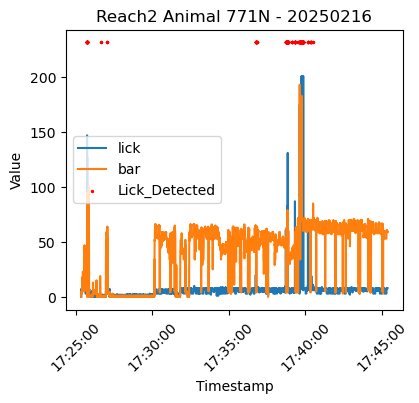

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


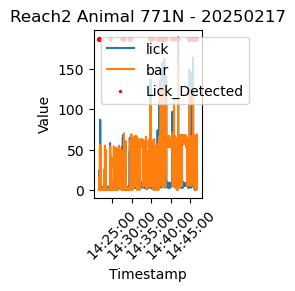

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


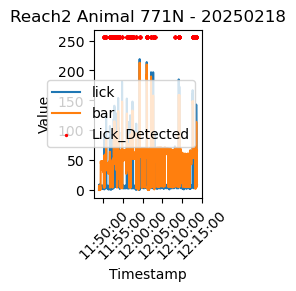

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


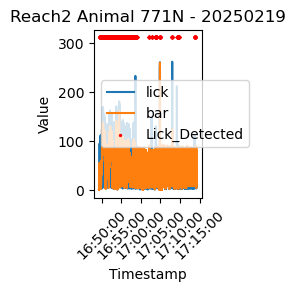

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


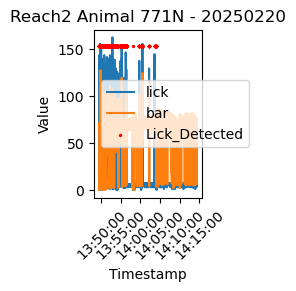

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


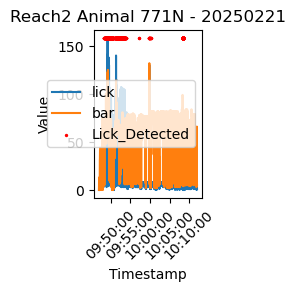

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


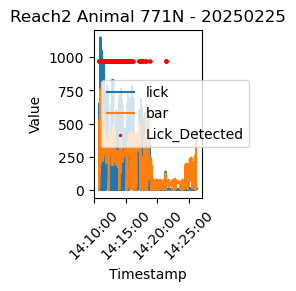

<Figure size 640x480 with 0 Axes>

In [18]:
# Example usage:
data_dir = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
fig = plot_animal_sessions('771N', data_dir, plot_type='basic', session_type='Reach')
plt.show()

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


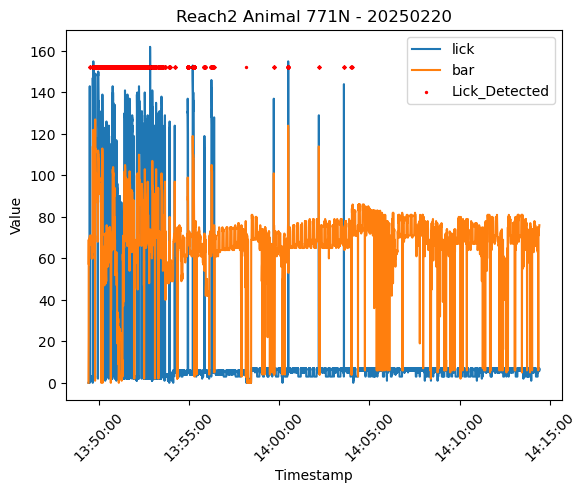

Sensor
bar     105.719421
lick    134.426670
Name: Time_Diff, dtype: float64


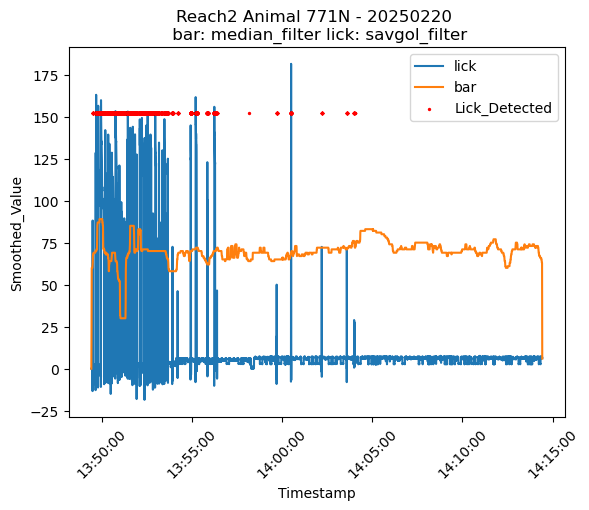

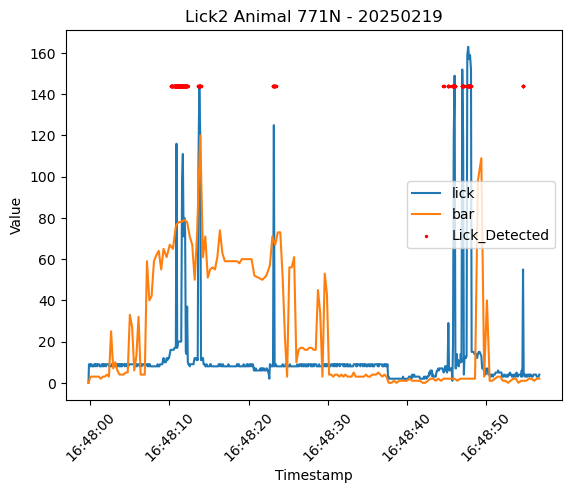

Sensor
bar     129.954516
lick    132.766861
Name: Time_Diff, dtype: float64


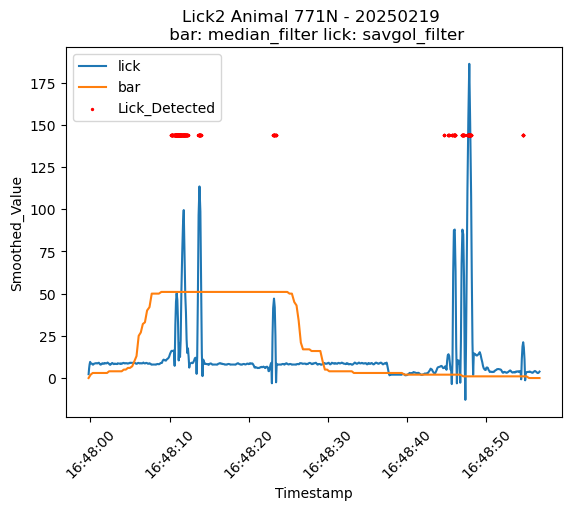

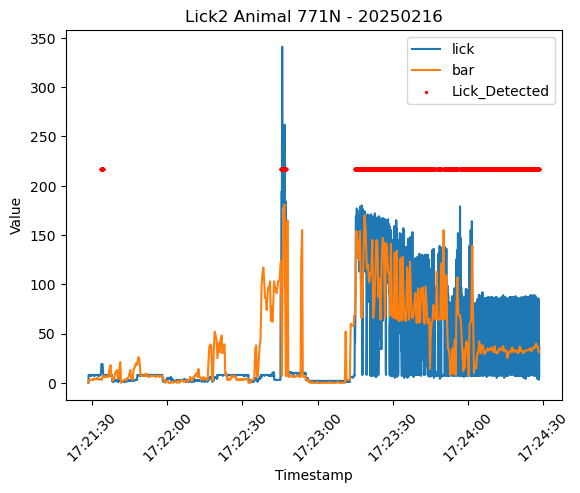

Sensor
bar     123.609394
lick    124.657193
Name: Time_Diff, dtype: float64


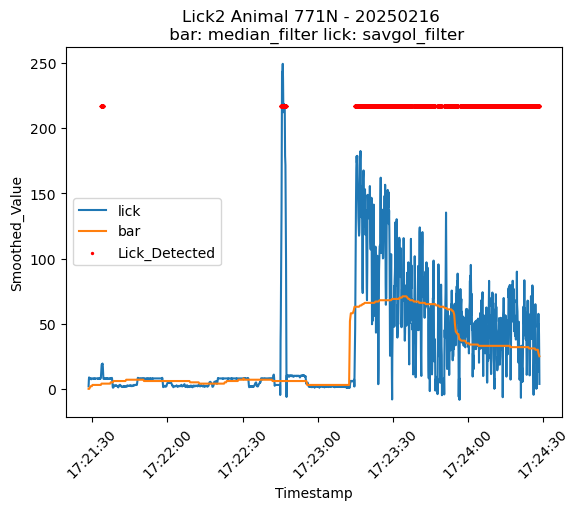

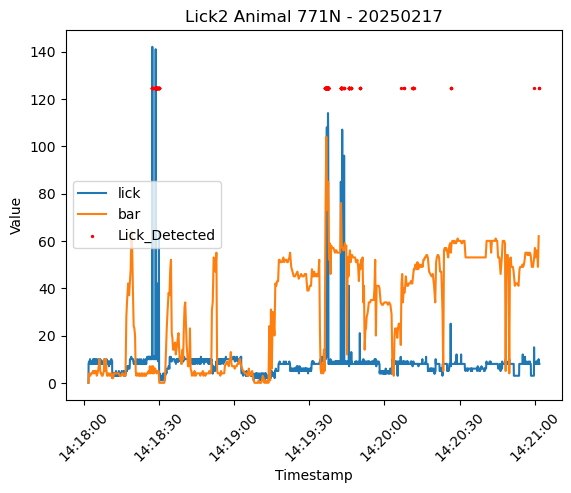

Sensor
bar     127.762872
lick    142.287991
Name: Time_Diff, dtype: float64


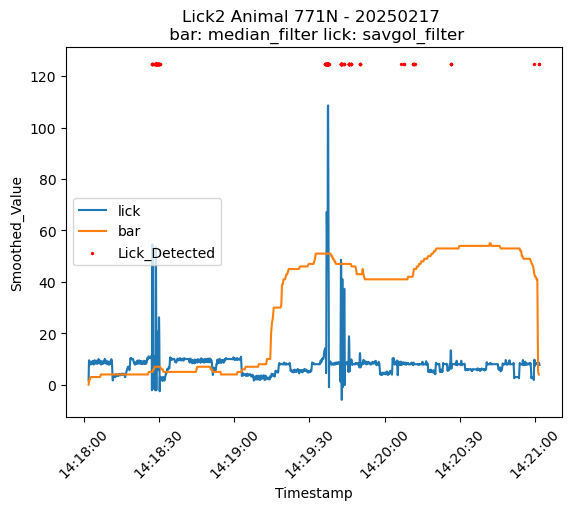

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


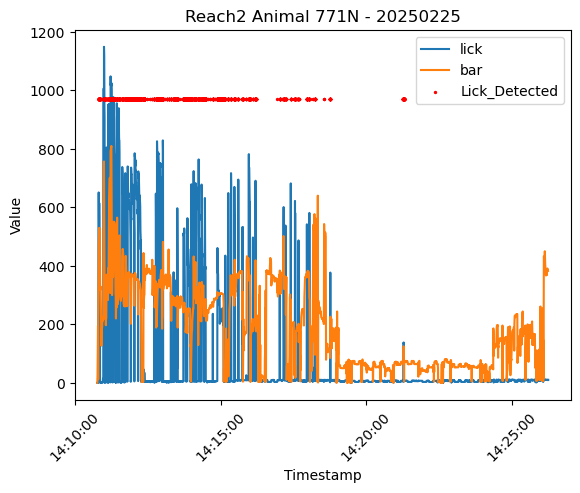

Sensor
bar      88.888889
lick    106.746371
Name: Time_Diff, dtype: float64


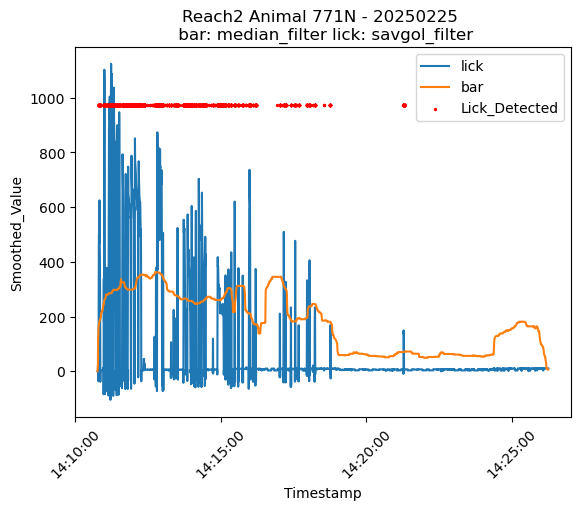

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


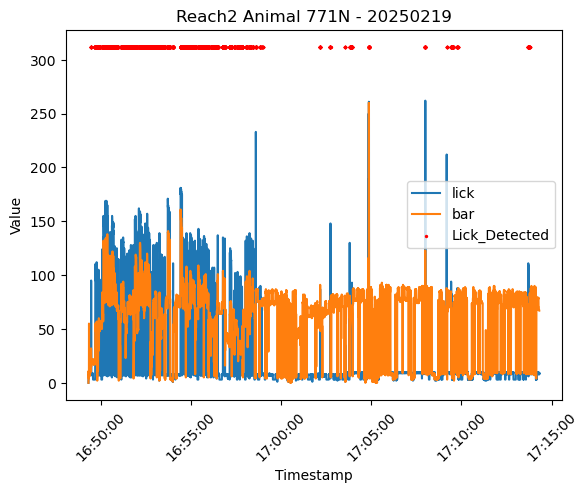

Sensor
bar     114.968958
lick    129.718511
Name: Time_Diff, dtype: float64


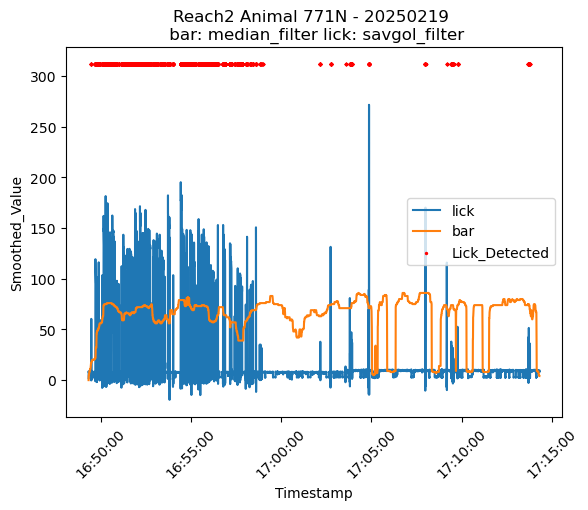

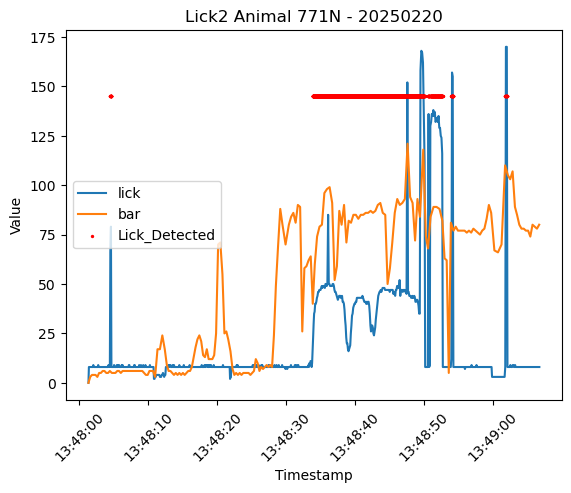

Sensor
bar     128.518185
lick    131.821777
Name: Time_Diff, dtype: float64


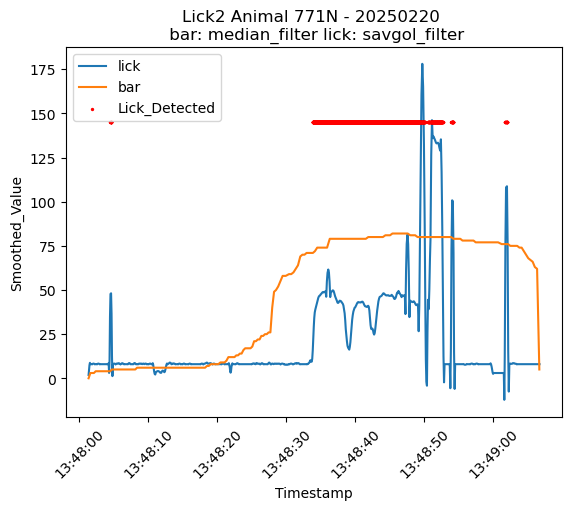

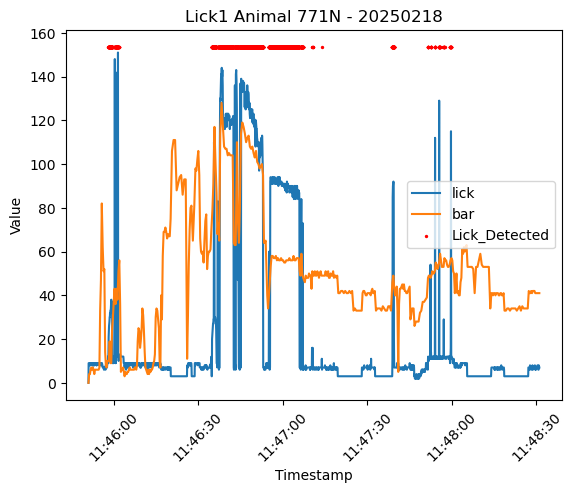

Sensor
bar     116.063138
lick    137.931034
Name: Time_Diff, dtype: float64


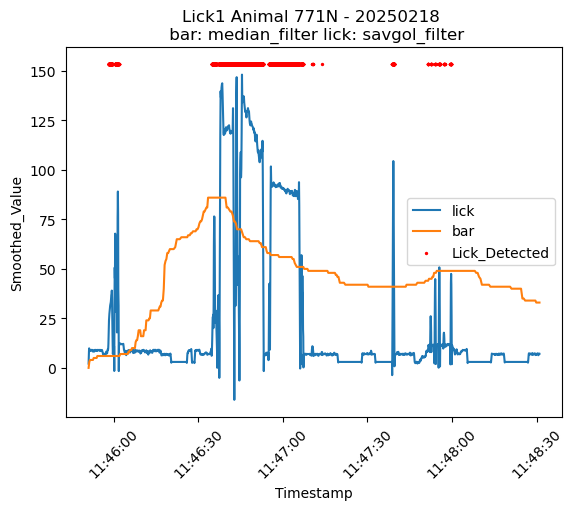

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


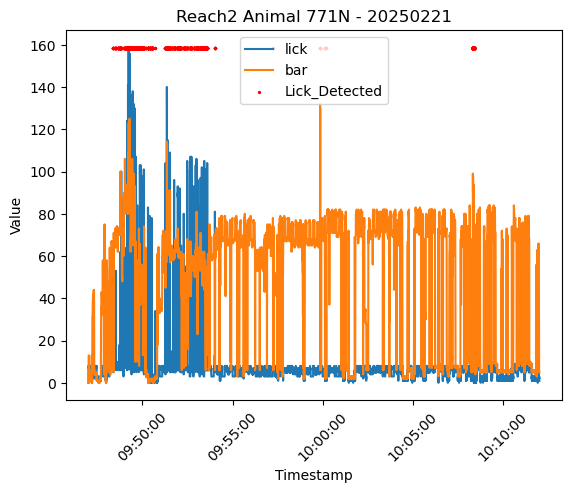

Sensor
bar     116.563702
lick    134.843581
Name: Time_Diff, dtype: float64


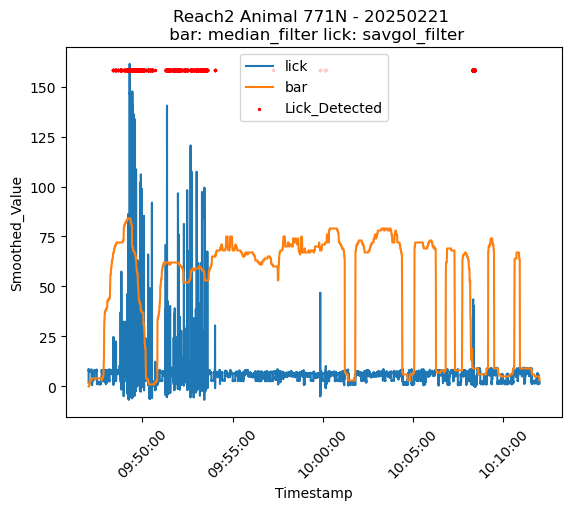

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


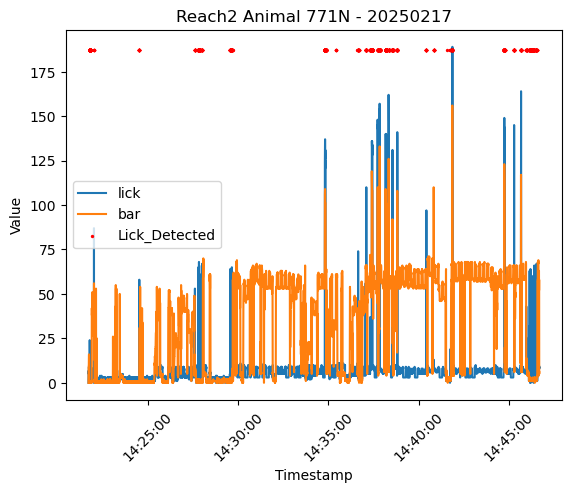

Sensor
bar     115.580213
lick    138.504155
Name: Time_Diff, dtype: float64


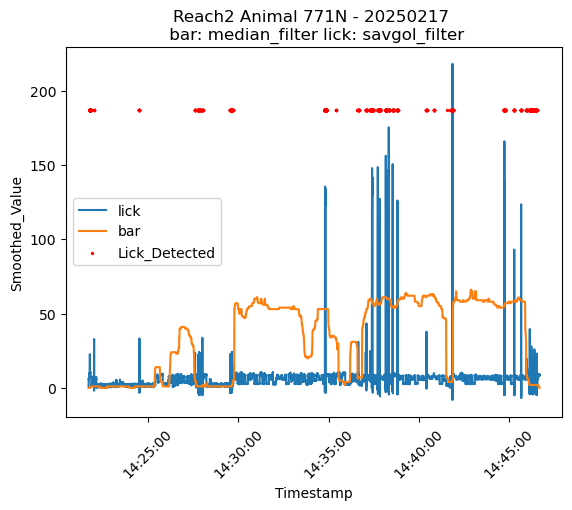

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


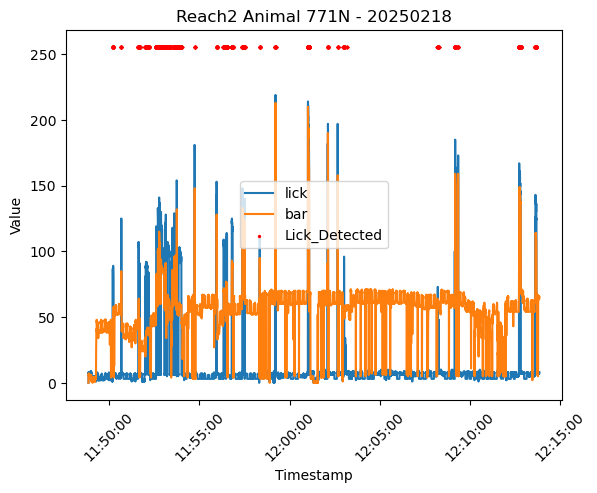

Sensor
bar     110.424028
lick    140.805407
Name: Time_Diff, dtype: float64


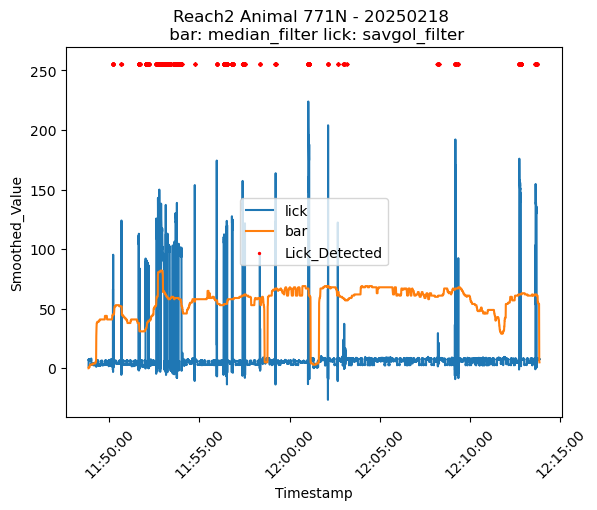

/var/folders/vk/jj53gpcd0rbcvpd1cnr0nqlw0000gn/T/ipykernel_94385/2648957660.py:29: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')


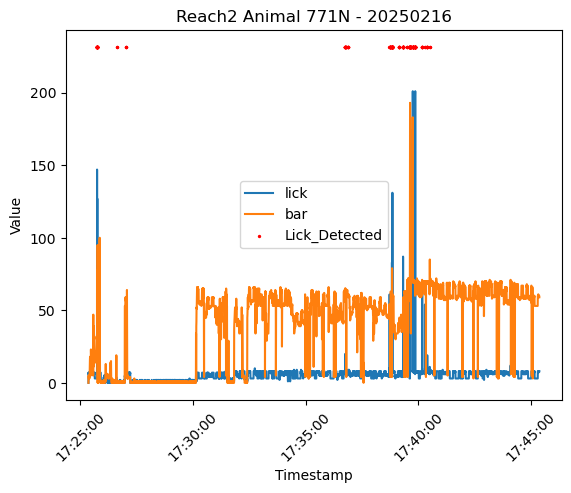

Sensor
bar     113.186191
lick    138.696255
Name: Time_Diff, dtype: float64


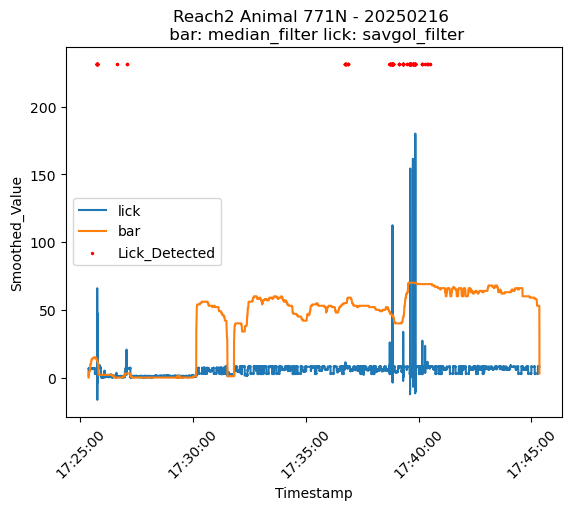

In [12]:
#NEED TO FIX GET_TXT_DF TO BE ABLE TO PLOT ALL SESSIONS , REINDEX WAS CUSTOMIZED AND DOESNT NOT APPLY TO NEW TXT FILES UGH
'''despite agg. capability, this is not the best place to aggeregate the data
should summarize after you have some performance criteria. 
use this script for visualization of performance criteria as you develop them'''
animal_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/771N'
#get list of behav files 
txt_files = get_txt_path(animal_path)
#parse to extract animal_ID, stage, and timestamp
pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})")
#initialize master df 
##behav_df = pd.DataFrame()
i=0
for txt in txt_files:
    filename = os.path.basename(txt)
    #get parsed df 
    df = get_txt_df(txt)
    match = pattern.match(filename)
    if match:
        animal_ID = match.group(1)
        stage = match.group(2)
        date = match.group(3)
        start_time = match.group(4)
    else:
        raise ValueError('filename does not have correct pattern')
    #add identifiers to the df 
    df['Animal_ID'] = animal_ID
    df['Stage'] = stage
    df['Date'] = date
    df['Start'] = start_time
    #if recording before 6 am, set the date back one day

    # Convert start_time to a datetime object to check the hour
    start_time = pd.to_datetime(start_time, format='%H%M%S')
    # Adjust Date if Start time is before 6 AM
    if start_time.hour < 6:
        df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d') - pd.Timedelta(days=1)
    else:
        df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    
    basic_plot(df, animal_ID = animal_ID, date=date, stage=stage, dots=True, which_dots='Lick_Detected')
    fs = get_sampling_rate(df) #prev used as inputs to lowpass filter
    smoothed_plot(df, animal_ID = animal_ID, date=date, stage=stage, kernel_size = 99, dots=True, which_dots='Lick_Detected')
    ##behav_df = pd.concat([behav_df,df],sort=False)
    i+=1
   #if i>3:
        #break  
    

In [ ]:
#interim pausing on how to get a sort of num correct and num failed trails. (requires weird timing things)
#probably do need to address the error from reindexing when reading into a dataframe.. 
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
#get list of behav files 
txt_files = get_txt_path(data_path)
#parse to extract animal_ID, stage, and timestamp
pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})")
#initialize behav df 
behav_df = pd.DataFrame()
i=0
for txt in txt_files:
    filename = os.path.basename(txt)
    try:
        #get parsed df 
        df = get_txt_df(txt)
        match = pattern.match(filename)
        if match:
            animal_ID = match.group(1)
            stage = match.group(2)
            date = match.group(3)
            start_time = match.group(4)
        else:
            raise ValueError('filename does not have correct pattern')
        #get performance metrics
        bar_holds = df['Solenoid'].sum() #num of solenoid activations represents how many times bar was correctly held for 1.5 sec
        num_licks = df['Lick_Detected'].sum()
        dur = df['Timestamp'].max() - df['Timestamp'].min()
        # If recording before 6 am, set the date back one day
        # Convert start_time to a datetime object to check the hour
        start_time = pd.to_datetime(start_time, format='%H%M%S')
        # Adjust Date if Start time is before 6 AM
        if start_time.hour < 6:
            date = pd.to_datetime(date, format='%Y%m%d') - pd.Timedelta(days=1)
        else:
            date = pd.to_datetime(date, format='%Y%m%d')
        date = date.strftime('%Y-%m-%d')
        start_time = start_time.strftime('%H:%M:%S')
        #append data (identiying info + behav metrics)
        df_ = pd.DataFrame({
            'filename':[filename],
            'animal_ID':[animal_ID],
            'stage':[stage],
            'date':[date],
            'start':[start_time],
            'bar_holds':[bar_holds],
            'num_licks':[num_licks],
            'duration(min)':[dur.total_seconds()/60]
            })
        behav_df = pd.concat([behav_df,df_],sort=False,ignore_index=True)
        #basic visualization per session
        #basic_plot(df, animal_ID = animal_ID, date=date, stage=stage, dots=True, which_dots='Lick_Detected')
    except Exception as e:
        print(f"Error processing file: '{filename}' Error: {e}")
        continue
    i+=1
    #if i>3:
     #   break  

#SAVE to csv 
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
output_csv_path = os.path.join(save_path, "raw_behavior_summary.csv")
behav_df.to_csv(output_csv_path, index=False)
print(f"Saved measurements to {output_csv_path}")

In [ ]:
lick_df = df[df['Sensor']=='lick']
# Calculate the baseline as a low percentile (e.g., 10th percentile)
baseline_value = lick_df['Value'].quantile(0.1)

# Calculate the standard deviation
stdev_value = lick_df['Value'].std()

# Set the threshold for detecting licks
threshold = baseline_value + 2 * stdev_value

# Detect licks above the threshold
num_licks = (lick_df['Value'] > threshold).sum()

print(f"Baseline Value (10th Percentile): {baseline_value}")
print(f"Standard Deviation: {stdev_value}")
print(f"Lick Detection Threshold: {threshold}")
print(f"Number of Licks Detected: {num_licks}")


In [ ]:
    #note, trials are being identified by when the solenoid open condition was activated, not by when the condition was met 
    #ie the conditions are tested by arduino to enable solenoid open, and we are trusting this and just saying when arduino says bar was held long enough this is a trial. 
    #but true trial start time would depend on when the mouse started to hold the bar, timing from last water droplet, etc. 

def trial_lick_detect(row,df):
    '''
    row : row of pandas df
    has trial start and trial end time
    df: this should be the df extracted from txt file with all sensor data. 
    filters parent df to individual trials using start and end times
    records if any lick was detected during that trial period
    '''
    mask = (df['Timestamp'] >= row['trial_start']) & (df['Timestamp']<= row['trial_end'])
    return int(df.loc[mask,'Lick_Detected'].any())
    
def trial_performance(filepath, min_bar_hold = 1.5, max_trial_dur = 10):
    '''
    trial start is reported as time conditions were met to open solenoid, but true trial start time would require
    (a) knowing how long the mouse needs to hold the bar and (b) trial history. min_bar_hold should be identified from the txt file and used for this purpose.
    in get_txt_df - solenoid activated is reported once per trial. so luckily this is an okay metric to use
    the analysis of lick_detected/total_trials will tell us "of the succesful bar holds, how many were succesful reaches"
    '''
    df = get_txt_df(filepath)
    trial_start = df[df['Solenoid']==True]['Timestamp'].reset_index(drop=True)
    #get trial_dur by measuring time between solenoid activations. min btw duration and 10 sec will be selected.  
    trial_dur = trial_start.diff().shift(-1) #diff between previous and next timestamp
    trial_dur = trial_dur.dt.total_seconds().fillna(min_bar_hold) 
    #determine trial end time estimate and max
    trial_end_est = trial_start + pd.to_timedelta(trial_dur, unit='s')
    trial_end_max = trial_start + pd.to_timedelta(max_trial_dur, unit='s')
    # For each trial, take the minimum of trial_end or trial_start + max_trial_dur
    trial_end = trial_end_est.combine(trial_end_max, min)
    #create trial_df 
    trial_df = pd.DataFrame({
        'trial_start': trial_start,
        'trial_end': trial_end
        })
    #apply trial_lick function to get lick detection per trial (passes each row of trial_df to trial_lick_detect)
    trial_df['Lick_Detected'] = trial_df.apply(trial_lick_detect, axis=1,df=df)
    #report trial start time, trial duration, if lick detected in trial in a new compressed df 
    return trial_df

#test trial_performance function 
'''min_bar_hold = 1.5 #sec
max_trial_dur = 10 #sec
filepath = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/808T/808T_LickReach_20240909_170952.txt'
trial_perf = trial_performance(filepath, min_bar_hold, max_trial_dur)'''

def sess_performance(filepath, min_bar_hold=1.5, max_trial_dur=10):
    '''
    the session start and session end time is incorrect here. it is chosen based off first solenoid activation
    but the session could have lasted much longer than the trial_start_end min/max times. 
    we need to just go into the txt file and get first and last timestamps (get_txt_df_)

    '''
    df = get_txt_df(filepath)
    trial_df = trial_performance(filepath, min_bar_hold, max_trial_dur)
    total_trials = len(trial_df)
    lick_trials = trial_df['Lick_Detected'].sum()
    
    dur = (df['Timestamp'].max() - df['Timestamp'].min())
    session_duration = dur.total_seconds()/60
    
    filename = os.path.basename(filepath)
    match = re.match(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})", filename)
    if match:
        animal_ID, stage, date, start_time = match.groups()
    else:
        raise ValueError(f"Filename '{filename}' does not match pattern")
    
    start_time = pd.to_datetime(start_time, format='%H%M%S')
    if start_time.hour < 6:
        date = pd.to_datetime(date, format='%Y%m%d') - pd.Timedelta(days=1)
    else:
        date = pd.to_datetime(date, format='%Y%m%d')
    
    return pd.DataFrame({
        'filename': [filename],
        'animal_ID': [animal_ID],
        'stage': [stage],
        'date': [date.strftime('%Y-%m-%d')],
        'start': [start_time.strftime('%H:%M:%S')],
        'total_trials': [total_trials],
        'lick_trials': [lick_trials],
        'duration_min': [session_duration]
    })

In [ ]:
data_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data'
txt_files = get_txt_path(data_path)  # This should return a list of file paths
pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8})_(\d{6})")

behav_summary = pd.DataFrame()

for txt in txt_files:
    try:
        # Use the session performance function to get summarized metrics for each session
        sess_summary = sess_performance(txt)
        # Append the summary to the main DataFrame
        behav_summary = pd.concat([behav_summary, sess_summary], ignore_index=True, sort=False)
    except Exception as e:
        print(f"Error processing file: '{txt}' Error: {e}")
        continue

#SAVE to csv 
save_path = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary'
output_csv_path = os.path.join(save_path, "behavior_summary.csv")
behav_summary.to_csv(output_csv_path, index=False)
print(f"Saved measurements to {output_csv_path}")

In [ ]:
#%% DELETE OR MOVE ALL OF THIS SOMEWHERE ELSE PLEASE ITS LIKE TOO MESSY FOR THIS SCRIPT

In [ ]:
#behav_summary = pd.read_csv('/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary/behavior_summary.csv')
behav_summary['p_lick_trials'] = 100*behav_summary['lick_trials']/behav_summary['total_trials']

In [ ]:
animal277N = behav_summary[behav_summary['animal_ID']=='277N']
animal277N = animal277N[animal277N['duration_min']>10]
#plt.plot()
animal277T = behav_summary[behav_summary['animal_ID']=='277T']
animal277T = animal277T[animal277T['duration_min']>10]

In [ ]:
#behav_summary = behav_summary.replace('4932T','4432T')
animal4432T = behav_summary[behav_summary['animal_ID']=='4432T']
animal4432T = animal4432T[animal4432T['duration_min']>10]

In [ ]:
behav_summary = behav_summary.replace('4944T','4844T')
animal4844T = behav_summary[behav_summary['animal_ID']=='4844T']
animal4844T = animal4844T[animal4844T['duration_min']>10]

In [ ]:
animal808T = behav_summary[behav_summary['animal_ID']=='808T']
animal808T = animal808T[animal808T['duration_min']>10]
#plt.plot()
animal807T = behav_summary[behav_summary['animal_ID']=='807T']
animal807T = animal807T[animal807T['duration_min']>10]

In [ ]:
animal806N = behav_summary[behav_summary['animal_ID']=='806N']
animal806N = animal806N[animal806N['duration_min']>10]

In [ ]:
animal770N = behav_summary[behav_summary['animal_ID']=='770N']
animal770N = animal770N[animal770N['duration_min']>10]

animal771N = behav_summary[behav_summary['animal_ID']=='771N']
animal771N = animal771N[animal771N['duration_min']>10]

animal772N = behav_summary[behav_summary['animal_ID']=='772N']
animal772N = animal772N[animal772N['duration_min']>10]

In [ ]:
animal770N = animal770N.sort_values(by='date')
sns.scatterplot(data = animal770N, x ='date',y='lick_trials', hue='stage')
plt.title('770N')
plt.xticks(rotation=45)

plt.figure()

animal771N = animal771N.sort_values(by='date')
sns.scatterplot(data = animal771N, x ='date',y='lick_trials', hue='stage')
plt.title('771N')
plt.xticks(rotation=45)

plt.figure()

animal772N = animal772N.sort_values(by='date')
sns.scatterplot(data = animal772N, x ='date',y='lick_trials', hue='stage')
plt.title('772N')
plt.xticks(rotation=45)


In [ ]:
animal277N = animal277N.sort_values(by='date')
sns.scatterplot(data = animal277N, x ='date',y='lick_trials', hue='stage')
plt.title('277N')
plt.xticks(rotation=45)

In [ ]:
animal277T = animal277T.sort_values(by='date')
sns.scatterplot(data = animal277T, x ='date',y='lick_trials', hue='stage')
plt.title('277T')
plt.xticks(rotation=45)

In [ ]:
animal4432T = animal4432T.sort_values(by='date')
sns.scatterplot(data = animal4432T, x ='date',y='lick_trials', hue='stage')
plt.title('4432T')

In [ ]:
animal4844T = animal4844T.sort_values(by='date')
sns.scatterplot(data = animal4844T, x ='date',y='lick_trials', hue='stage')
plt.title('4844T')

In [ ]:
animal808T = animal808T.sort_values(by='date')
sns.scatterplot(data = animal808T, x ='date',y='lick_trials', hue='stage')
plt.title('808T')
plt.xticks(rotation=45)

In [ ]:
animal807T = animal807T.sort_values(by='date')
sns.scatterplot(data = animal807T, x ='date',y='lick_trials', hue='stage')
plt.title('807T')
plt.xticks(rotation=45)

In [ ]:
animal806N = animal806N.sort_values(by='date')
sns.scatterplot(data = animal806N, x ='date',y='lick_trials', hue='stage')
plt.title('806N')
plt.xticks(rotation=45)


In [ ]:
animal277N = animal277N.sort_values(by='date')
sns.scatterplot(data = animal277N, x ='date',y='p_lick_trials', hue='stage')
plt.title('277N')
plt.xticks(rotation=45)

In [ ]:
animal277T = animal277T.sort_values(by='date')
sns.scatterplot(data = animal277T, x ='date',y='p_lick_trials', hue='stage')
plt.title('277T')
plt.xticks(rotation=45)

In [ ]:
animal4432T = animal4432T.sort_values(by='date')
sns.scatterplot(data = animal4432T, x ='date',y='p_lick_trials', hue='stage')
plt.title('4432T')
plt.xticks(rotation=45)

In [ ]:
animal4844T = animal4844T.sort_values(by='date')
sns.scatterplot(data = animal4844T, x ='date',y='p_lick_trials', hue='stage')
plt.title('4844T')

In [ ]:
animal808T = animal808T.sort_values(by='date')
sns.scatterplot(data = animal808T, x ='date',y='p_lick_trials', hue='stage')
plt.title('808T')
plt.xticks(rotation=45)

In [ ]:
animal807T = animal807T.sort_values(by='date')
sns.scatterplot(data = animal807T, x ='date',y='p_lick_trials', hue='stage')
plt.title('807T')
plt.xticks(rotation=45)

In [ ]:
animal806N = animal806N.sort_values(by='date')
sns.scatterplot(data = animal806N, x ='date',y='p_lick_trials', hue='stage')
plt.title('806N')
plt.xticks(rotation=45)

In [ ]:
bh_df = pd.read_csv('/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/data_summary/raw_behavior_summary.csv')
bh_df['date'] = pd.to_datetime(bh_df['date'])
bh_df = bh_df.sort_values(by='date')
sns.scatterplot(data=bh_df, x='date',y='bar_holds',hue='stage')

In [ ]:
def analyze_trials(df):
    # Ensure Timestamp is in datetime format
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    # Create a list to store trial information
    trials = []
    
    # Filter solenoid activation events
    solenoid_df = df[df['Solenoid'] == True]
    
    for i, solenoid_row in solenoid_df.iterrows():
        # Trial starts at solenoid activation
        trial_start = solenoid_row['Timestamp']
        
        # Find the next solenoid activation or the end of the dataframe
        if i + 1 < len(solenoid_df):
            next_solenoid = solenoid_df.iloc[i + 1]['Timestamp']
        else:
            next_solenoid = df['Timestamp'].max()  # End of the dataframe
            
        # Trial ends either after 10 seconds or at the next solenoid activation, whichever comes first
        trial_end = min(trial_start + pd.Timedelta(seconds=10), next_solenoid)
        
        # Filter data for the current trial
        trial_data = df[(df['Timestamp'] >= trial_start) & (df['Timestamp'] < trial_end)]
        
        # Check if a lick was detected within the trial
        lick_detected = trial_data['Lick_Detected'].any()
        
        # Append trial information to the list
        trials.append({
            'Trial_Start': trial_start,
            'Trial_End': trial_end,
            'Lick_Detected': lick_detected
        })
    
    # Convert the trial information into a DataFrame for analysis
    trial_df = pd.DataFrame(trials)
    
    # Calculate total number of trials and trials where a lick was detected
    total_trials = len(trial_df)
    trials_with_lick = trial_df['Lick_Detected'].sum()

    return total_trials, trials_with_lick, trial_df


In [ ]:
dirpath = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/808T'
filename = '808T_Lick_20240813_223132.txt'
#do direcotry walk thing to filter through them
filepath = os.path.join(dirpath,filename)
df = pd.read_csv(filepath, sep='-', header=None, on_bad_lines='skip')
df = df.reset_index()
#alt labels = df.columns[-2:]
df.drop(labels=['index',2,3],axis=1,inplace=True)
df.rename(columns={0: 'Timestamp', 1: 'Print'}, inplace=True)
df['Sensor'] = df['Print'].str.extract(r'(lick|bar)', expand=False)
df['Value'] = df['Print'].str.extract(r'(\d+)', expand=False).astype(float)
#df['Solenoid'] = df['Print'].str.contains('Solenoid Activated').astype(bool)
df.drop(labels=['Print'],axis=1,inplace=True)
#df = df[~(df['Sensor'].isna() & (df['Solenoid'] == 0))]
#df.dropna(axis=0,inplace=True)
df = df.sort_values(by='Timestamp')
# Regular expression to extract animal_ID, stage, and timestamp
pattern = re.compile(r"(\d{3,4}[A-Z])_(.+?)_(\d{8}_\d{6})")
# Extracting the components from the filename
match = pattern.match(filename)
if match:
    animal_ID = match.group(1)
    stage = match.group(2)
    timestamp = match.group(3)
else:
    raise ValueError("Filename format does not match the expected pattern.")

df['Animal_ID'] = animal_ID
df['Stage'] = stage
df['File_Timestamp'] = timestamp


In [ ]:

def trial_lick(row,df):
    '''extract each set between trial_start and trial_end to see if lick_detected, try not to use for loop operation 
    record binary value if lick detected
        '''
    mask = (df['Timestamp'] >= row['trial_start']) & (df['Timestamp']<= row['trial_end'])
    return int(df.loc[mask,'Lick_Detected'].any())

min_bar_hold = 1.5 #sec
max_trial_dur = 10 #sec
filepath = '/Users/emmaodom/Dropbox (MIT)/Emma/Reach_Task_Master/lick_reaching_data/808T/808T_LickReach_20240909_170952.txt'
df = get_txt_df(filepath)
trial_start = df[df['Solenoid']==True]['Timestamp'].reset_index(drop=True)
trial_dur = trial_start.diff().shift(-1) #diff between previous and next timestamp
trial_dur = trial_dur.dt.total_seconds().fillna(min_bar_hold) 
#trial_end as next solenoid activation time OR 10 seconds after start of current trial (within row). choose lowest value 
    #trial_end = min(trial_start+trial_dur,10)
trial_end_est = trial_start + pd.to_timedelta(trial_dur, unit='s')
trial_end_10sec = trial_start + pd.to_timedelta(max_trial_dur, unit='s')

# For each trial, take the minimum of trial_end or trial_start + 10 seconds
trial_end = pd.DataFrame({'trial_end': trial_end_est, 'trial_end_10sec': trial_end_10sec}).min(axis=1)
#create trial_df 
trial_df = pd.DataFrame({
    'trial_start': trial_start,
    'trial_end': trial_end
    })
#apply trial_lick function to get lick detection per trial (passes each row of trial_df to trial_lick_detect)
trial_df['Lick_Detected'] = trial_df.apply(trial_lick, axis=1,df=df)
#report trial start time, trial duration, if lick detected in trial in a new compressed df 
print(trial_df)
